# 03_ProductivityAssistant.ipynb

## Applying a Fuzzy Cognitive Map to a Productivity Assistant

This notebook applies the **scenario simulation / intervention** approach from the FCM tutorials to a domain related to our group project: a **productivity assistant**.

### Goal
Model how different factors interact in a student's daily productivity system and test whether an assistant that reduces distractions and improves planning can improve outcomes.

### Concepts
We use the following concepts:

- **TaskLoad**: amount of pending work
- **Notifications**: interruptions from phone/laptop/apps
- **PlanningQuality**: how well the day is structured
- **SleepQuality**: rest and recovery
- **Stress**: pressure / overwhelm
- **Focus**: ability to concentrate
- **Productivity**: effective output

The notebook includes:
1. a hand-crafted FCM weight matrix,
2. a simulation function,
3. a baseline scenario,
4. an intervention scenario,
5. a comparison and interpretation.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Define the FCM structure

The weight matrix encodes causal influence between concepts.

- Positive values mean **an increase in concept A increases concept B**
- Negative values mean **an increase in concept A decreases concept B**
- Values closer to `1` or `-1` indicate stronger influence

Rows are **source concepts** and columns are **target concepts**.


In [15]:
concepts = [
    "TaskLoad",
    "Notifications",
    "PlanningQuality",
    "SleepQuality",
    "Stress",
    "Focus",
    "Productivity",
]

W = pd.DataFrame(
    [
        # TL    N     PQ    SQ    S     F     P
        [0.00, 0.00, 0.00, 0.00, 0.80, -0.30, -0.40],  # TaskLoad
        [0.00, 0.00, 0.00, 0.00, 0.60, -0.80, -0.30],  # Notifications
        [-0.20, 0.00, 0.00, 0.00, -0.50, 0.70, 0.60],  # PlanningQuality
        [0.00, 0.00, 0.00, 0.00, -0.60, 0.70, 0.30],   # SleepQuality
        [0.20, 0.00, -0.10, -0.30, 0.00, -0.70, -0.80],# Stress
        [-0.10, 0.00, 0.20, 0.10, -0.30, 0.00, 0.90],  # Focus
        [-0.40, 0.00, 0.30, 0.10, -0.20, 0.30, 0.00],  # Productivity
    ],
    index=concepts,
    columns=concepts,
)

W.round(2)

,TaskLoad,Notifications,PlanningQuality,SleepQuality,Stress,Focus,Productivity
TaskLoad,0.0,0.0,0.0,0.0,0.8,-0.3,-0.4
Notifications,0.0,0.0,0.0,0.0,0.6,-0.8,-0.3
PlanningQuality,-0.2,0.0,0.0,0.0,-0.5,0.7,0.6
SleepQuality,0.0,0.0,0.0,0.0,-0.6,0.7,0.3
Stress,0.2,0.0,-0.1,-0.3,0.0,-0.7,-0.8
Focus,-0.1,0.0,0.2,0.1,-0.3,0.0,0.9
Productivity,-0.4,0.0,0.3,0.1,-0.2,0.3,0.0


## 2. Initial state

This baseline represents a fairly typical busy student situation:

- high task load,
- many notifications,
- medium planning,
- average sleep,
- already some stress,
- reduced focus,
- only moderate productivity.


In [16]:
initial_state = pd.Series(
    {
        "TaskLoad": 0.85,
        "Notifications": 0.75,
        "PlanningQuality": 0.45,
        "SleepQuality": 0.55,
        "Stress": 0.65,
        "Focus": 0.35,
        "Productivity": 0.40,
    }
)

initial_state

TaskLoad           0.85
Notifications      0.75
PlanningQuality    0.45
SleepQuality       0.55
Stress             0.65
Focus              0.35
Productivity       0.40
dtype: float64

## 3. Simulation function

To keep the notebook self-contained, we implement a simple FCM update rule:

$$
x_{t+1} = \sigma(x_t + x_tW + u)
$$

where:
- `x_t` is the current state,
- `W` is the weight matrix,
- `u` is an optional intervention vector,
- `σ` is the sigmoid activation function, keeping values in `[0,1]`.

This is close in spirit to the first tutorial, where a scenario is simulated over multiple iterations until it stabilizes.


In [17]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def simulate_fcm(initial_state, weight_matrix, steps=20, intervention=None):
    concepts = list(weight_matrix.columns)
    x = initial_state[concepts].astype(float).values
    W = weight_matrix.loc[concepts, concepts].values.astype(float)
    u = np.zeros(len(concepts)) if intervention is None else np.array([intervention.get(c, 0.0) for c in concepts], dtype=float)

    history = [x.copy()]
    for _ in range(steps):
        x = sigmoid(x + x @ W + u)
        history.append(x.copy())

    df = pd.DataFrame(history, columns=concepts)
    df.index.name = "Iteration"
    return df

baseline = simulate_fcm(initial_state, W, steps=20)
baseline.head()

,TaskLoad,Notifications,PlanningQuality,SleepQuality,Stress,Focus,Productivity
Iteration,,,,,,,
0,0.850000,0.750000,0.450000,0.550000,0.650000,0.350000,0.400000
1,0.667078,0.679179,0.639916,0.605874,0.738850,0.465057,0.516244
2,0.606795,0.663555,0.692943,0.618302,0.680000,0.557574,0.607983
3,0.575727,0.660059,0.714808,0.629683,0.635815,0.615137,0.673767
4,0.556978,0.659274,0.726390,0.638262,0.607764,0.648528,0.712636


## 4. Baseline scenario

Let's inspect how the concepts evolve without any support from the productivity assistant.


In [18]:
baseline.round(3)

,TaskLoad,Notifications,PlanningQuality,SleepQuality,Stress,Focus,Productivity
Iteration,,,,,,,
0,0.850,0.750,0.450,0.550,0.650,0.350,0.400
1,0.667,0.679,0.640,0.606,0.739,0.465,0.516
2,0.607,0.664,0.693,0.618,0.680,0.558,0.608
3,0.576,0.660,0.715,0.630,0.636,0.615,0.674
4,0.557,0.659,0.726,0.638,0.608,0.649,0.713
5,0.546,0.659,0.733,0.644,0.590,0.668,0.734
6,0.539,0.659,0.736,0.647,0.580,0.679,0.746
7,0.535,0.659,0.738,0.649,0.574,0.685,0.753
8,0.533,0.659,0.740,0.650,0.570,0.688,0.757


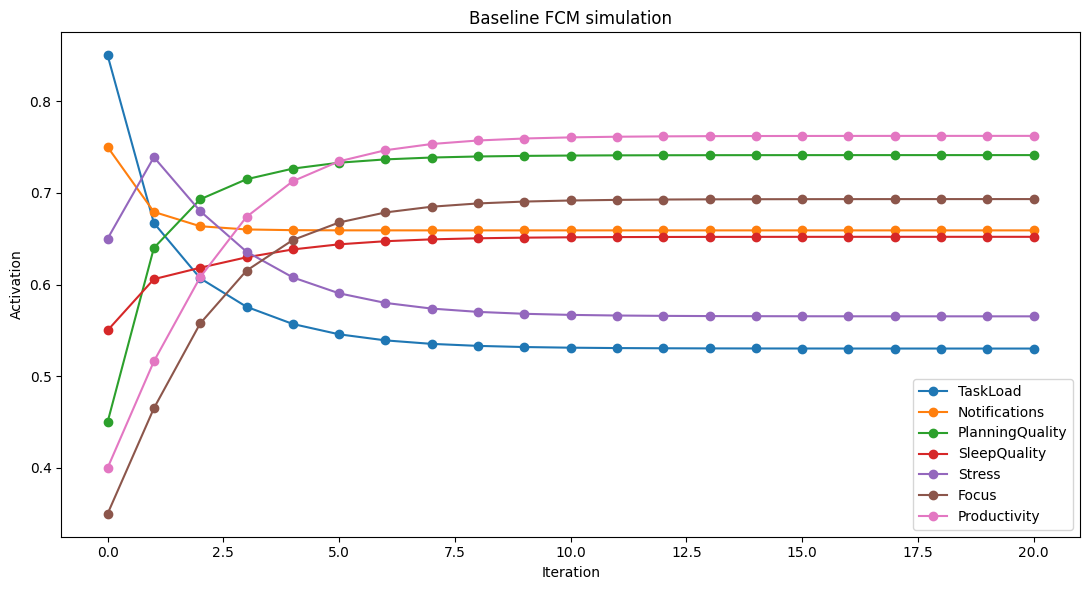

In [19]:
ax = baseline.plot(figsize=(11, 6), marker="o")
ax.set_title("Baseline FCM simulation")
ax.set_xlabel("Iteration")
ax.set_ylabel("Activation")
plt.tight_layout()
plt.show()

### Baseline interpretation

We will compare the first and final values to see the overall tendency.


In [20]:
baseline_summary = pd.DataFrame({
    "Initial": baseline.iloc[0],
    "Final": baseline.iloc[-1],
    "Change": baseline.iloc[-1] - baseline.iloc[0],
}).round(3)

baseline_summary.sort_values("Change", ascending=False)

,Initial,Final,Change
Productivity,0.40,0.762,0.362
Focus,0.35,0.693,0.343
PlanningQuality,0.45,0.741,0.291
SleepQuality,0.55,0.652,0.102
Stress,0.65,0.565,-0.085
Notifications,0.75,0.659,-0.091
TaskLoad,0.85,0.530,-0.320


In this baseline run:

- **Stress** stays high.
- **Focus** improves only partially.
- **Productivity** increases somewhat, but not dramatically.
- **Notifications** remain high because there is no mechanism reducing them.

This gives us a system where the student is coping, but not optimally.


## 5. Intervention scenario

Now we model a **productivity assistant** that:

- reduces distractions by filtering notifications,
- improves planning via reminders / task decomposition,
- gives calming structure that slightly lowers stress.

We encode this as a **continuous intervention**:
- `Notifications`: `-0.45`
- `PlanningQuality`: `+0.35`
- `Stress`: `-0.15`


In [21]:
assistant_intervention = {
    "Notifications": -0.45,
    "PlanningQuality": 0.35,
    "Stress": -0.15,
}

with_assistant = simulate_fcm(initial_state, W, steps=20, intervention=assistant_intervention)
with_assistant.round(3).head()

,TaskLoad,Notifications,PlanningQuality,SleepQuality,Stress,Focus,Productivity
Iteration,,,,,,,
0,0.850,0.750,0.450,0.550,0.650,0.350,0.400
1,0.667,0.574,0.716,0.606,0.709,0.465,0.516
2,0.602,0.531,0.776,0.620,0.616,0.596,0.632
3,0.564,0.520,0.798,0.636,0.550,0.674,0.717
4,0.540,0.518,0.809,0.648,0.509,0.716,0.763


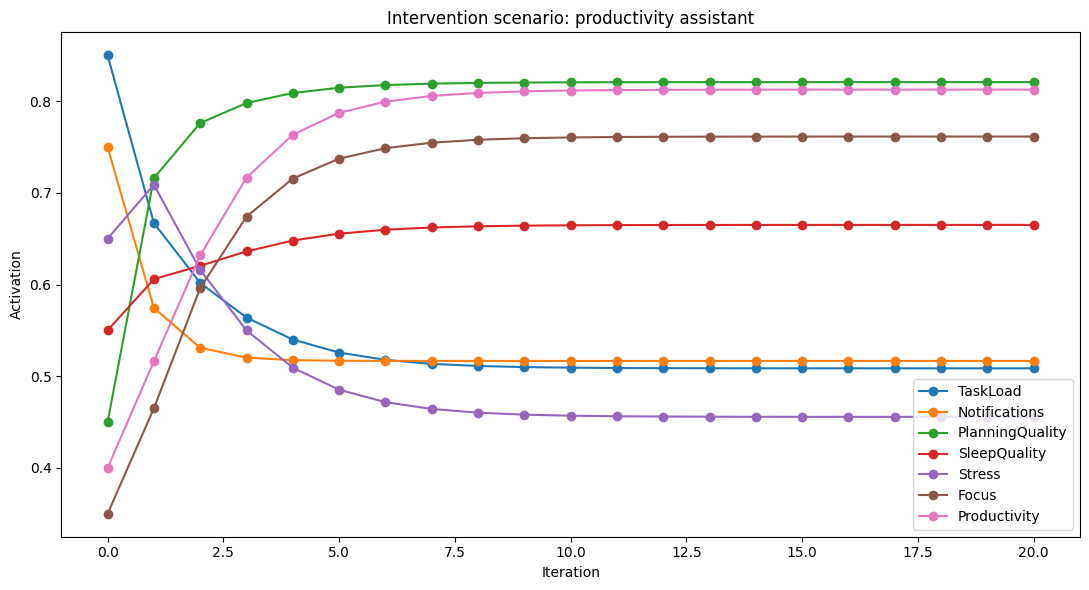

In [22]:
ax = with_assistant.plot(figsize=(11, 6), marker="o")
ax.set_title("Intervention scenario: productivity assistant")
ax.set_xlabel("Iteration")
ax.set_ylabel("Activation")
plt.tight_layout()
plt.show()

## 6. Compare baseline vs intervention

The most important concept for our project is **Productivity**, but we also care about **Focus**, **Stress**, and **PlanningQuality**.


In [23]:
comparison = pd.DataFrame({
    "Baseline_Final": baseline.iloc[-1],
    "Assistant_Final": with_assistant.iloc[-1],
})
comparison["Difference"] = comparison["Assistant_Final"] - comparison["Baseline_Final"]
comparison.round(3).sort_values("Difference", ascending=False)

,Baseline_Final,Assistant_Final,Difference
PlanningQuality,0.741,0.821,0.080
Focus,0.693,0.761,0.068
Productivity,0.762,0.813,0.050
SleepQuality,0.652,0.665,0.013
TaskLoad,0.530,0.509,-0.022
Stress,0.565,0.456,-0.110
Notifications,0.659,0.517,-0.142


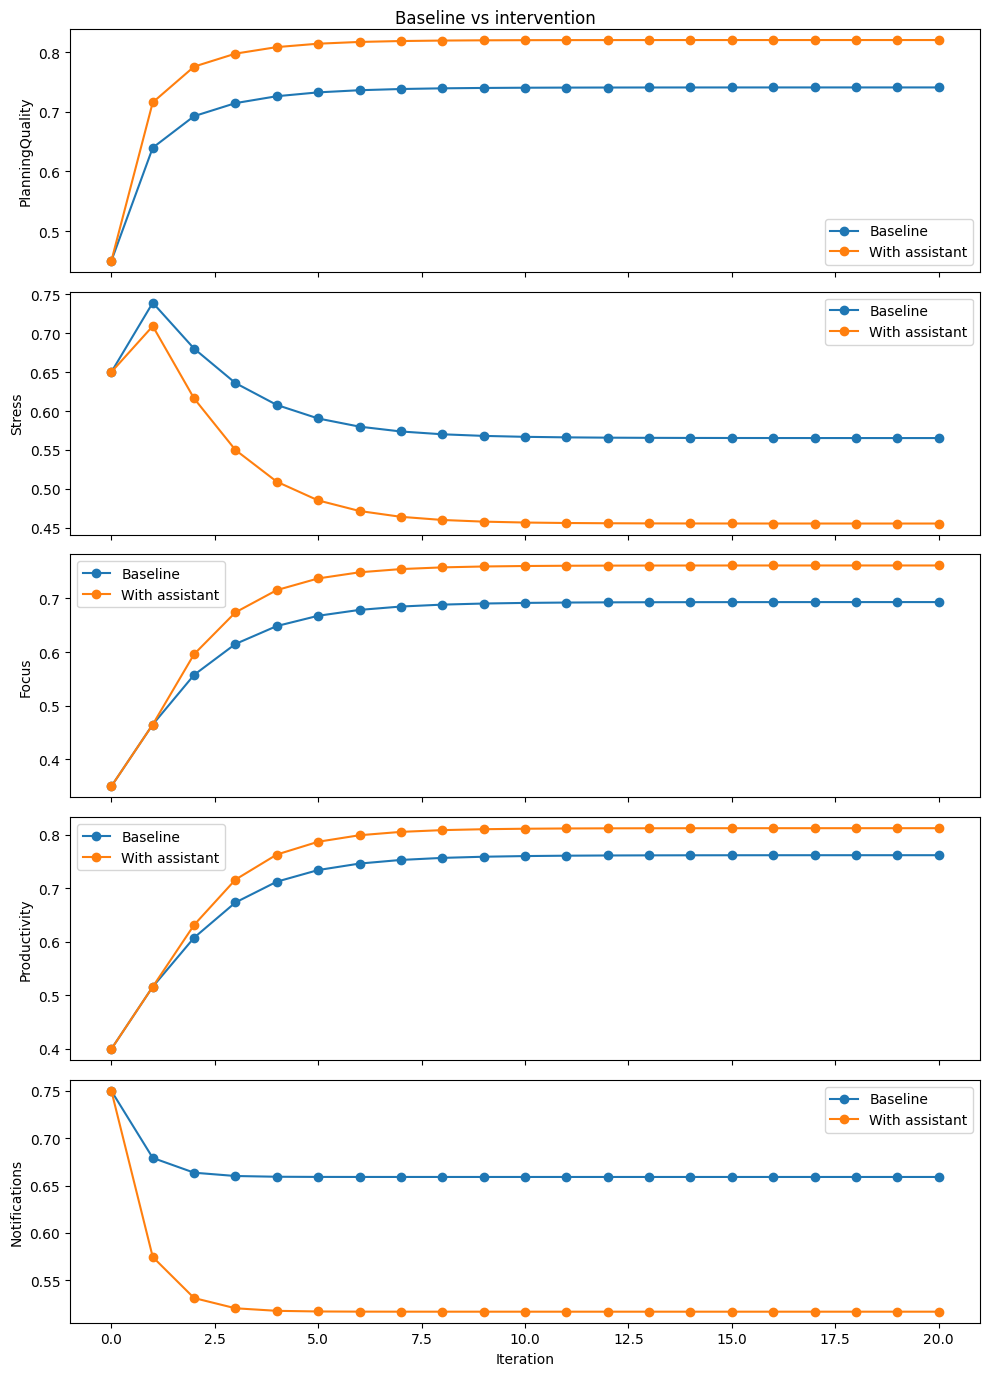

In [24]:
selected = ["PlanningQuality", "Stress", "Focus", "Productivity", "Notifications"]

fig, axes = plt.subplots(len(selected), 1, figsize=(10, 14), sharex=True)
for ax, concept in zip(axes, selected):
    ax.plot(baseline.index, baseline[concept], marker="o", label="Baseline")
    ax.plot(with_assistant.index, with_assistant[concept], marker="o", label="With assistant")
    ax.set_ylabel(concept)
    ax.legend()

axes[-1].set_xlabel("Iteration")
fig.suptitle("Baseline vs intervention")
plt.tight_layout()
plt.show()

## 7. Final discussion

### What we learned
This FCM suggests that a productivity assistant can improve the system mainly by:

1. **reducing notifications**, which removes a strong negative effect on focus,
2. **improving planning quality**, which helps focus and productivity,
3. **slightly reducing stress**, which prevents a negative spiral.

### Main result
Compared with the baseline, the intervention leads to:

- **higher PlanningQuality**
- **higher Focus**
- **higher Productivity**
- **lower Notifications**
- **slightly lower Stress**

### Why this fits the project
This is relevant for a productivity assistant because the assistant does not directly “create productivity.”  
Instead, it changes intermediate factors such as planning, distraction management, and stress, which then improve productivity indirectly.

## Conclusion
The **scenario / intervention approach** from Tutorial 01 works well for modeling a productivity assistant domain.  
It is interpretable, easy to explain, and useful for testing “what-if” questions before building a full system.
